 <div align="center"> <h1>New York City Borough Prediction.</h1>
 <div align="center"> <h5>Final Project</h5>


Importing all packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,OneHotEncoder,FunctionTransformer,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score,accuracy_score,ConfusionMatrixDisplay,classification_report
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as Imbpipeline
from imblearn.over_sampling import SMOTE
import tensorflow as tf

Reading data

In [2]:
df = pd.read_csv('NYC Property Sales.csv')

## Exploratory Data Analysis (EDA)

In [3]:
print(df.shape)

(84548, 22)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84548 entries, 0 to 84547
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Unnamed: 0                      84548 non-null  int64 
 1   BOROUGH                         84548 non-null  int64 
 2   NEIGHBORHOOD                    84548 non-null  object
 3   BUILDING CLASS CATEGORY         84548 non-null  object
 4   TAX CLASS AT PRESENT            84548 non-null  object
 5   BLOCK                           84548 non-null  int64 
 6   LOT                             84548 non-null  int64 
 7   EASE-MENT                       84548 non-null  object
 8   BUILDING CLASS AT PRESENT       84548 non-null  object
 9   ADDRESS                         84548 non-null  object
 10  APARTMENT NUMBER                84548 non-null  object
 11  ZIP CODE                        84548 non-null  int64 
 12  RESIDENTIAL UNITS               84548 non-null

In [5]:
#The data has ' -  ' values instead of null so replacing it wih np.nan and checking the null count
df.replace(' -  ',np.nan,inplace = True)
#Replacing 0 value in Year Built with np.nan
df['YEAR BUILT'] = df['YEAR BUILT'].replace(0,np.nan)
print(df.isna().sum())

Unnamed: 0                            0
BOROUGH                               0
NEIGHBORHOOD                          0
BUILDING CLASS CATEGORY               0
TAX CLASS AT PRESENT                  0
BLOCK                                 0
LOT                                   0
EASE-MENT                             0
BUILDING CLASS AT PRESENT             0
ADDRESS                               0
APARTMENT NUMBER                      0
ZIP CODE                              0
RESIDENTIAL UNITS                     0
COMMERCIAL UNITS                      0
TOTAL UNITS                           0
LAND SQUARE FEET                  26252
GROSS SQUARE FEET                 27612
YEAR BUILT                         6970
TAX CLASS AT TIME OF SALE             0
BUILDING CLASS AT TIME OF SALE        0
SALE PRICE                        14561
SALE DATE                             0
dtype: int64


In [6]:
print(df.duplicated().sum())

0


In [7]:
#Dropping null values and duplicates
df = df.drop_duplicates()
df = df.dropna()
print(df.shape)

(45333, 22)


In [8]:
print(df.dtypes)

Unnamed: 0                          int64
BOROUGH                             int64
NEIGHBORHOOD                       object
BUILDING CLASS CATEGORY            object
TAX CLASS AT PRESENT               object
BLOCK                               int64
LOT                                 int64
EASE-MENT                          object
BUILDING CLASS AT PRESENT          object
ADDRESS                            object
APARTMENT NUMBER                   object
ZIP CODE                            int64
RESIDENTIAL UNITS                   int64
COMMERCIAL UNITS                    int64
TOTAL UNITS                         int64
LAND SQUARE FEET                   object
GROSS SQUARE FEET                  object
YEAR BUILT                        float64
TAX CLASS AT TIME OF SALE           int64
BUILDING CLASS AT TIME OF SALE     object
SALE PRICE                         object
SALE DATE                          object
dtype: object


In [9]:
# changing the dtypes of the numeric column to interger
df[['LAND SQUARE FEET','GROSS SQUARE FEET','SALE PRICE','YEAR BUILT']] = df[['LAND SQUARE FEET','GROSS SQUARE FEET','SALE PRICE','YEAR BUILT']].astype(np.int64)
df['TAX CLASS AT TIME OF SALE'] = df['TAX CLASS AT TIME OF SALE'].astype('object')
print(df.dtypes)

Unnamed: 0                         int64
BOROUGH                            int64
NEIGHBORHOOD                      object
BUILDING CLASS CATEGORY           object
TAX CLASS AT PRESENT              object
BLOCK                              int64
LOT                                int64
EASE-MENT                         object
BUILDING CLASS AT PRESENT         object
ADDRESS                           object
APARTMENT NUMBER                  object
ZIP CODE                           int64
RESIDENTIAL UNITS                  int64
COMMERCIAL UNITS                   int64
TOTAL UNITS                        int64
LAND SQUARE FEET                   int64
GROSS SQUARE FEET                  int64
YEAR BUILT                         int64
TAX CLASS AT TIME OF SALE         object
BUILDING CLASS AT TIME OF SALE    object
SALE PRICE                         int64
SALE DATE                         object
dtype: object


In [10]:
#The targer variable is ordinal encoded to replacing it with names 
df['BOROUGH'] = df['BOROUGH'].map({1:'Manhattan',2:'Bronx',3:'Brooklyn',4:'Queens',5:'Staten Island'})

In [11]:
#Dropping columns that have no importance for analysis and have a lot a categorical variables
#Also dropping the columns that can cause data leakage like adress,zipcode
df.drop(['Unnamed: 0','ADDRESS','ZIP CODE','APARTMENT NUMBER','EASE-MENT','BUILDING CLASS AT PRESENT','BUILDING CLASS AT TIME OF SALE','NEIGHBORHOOD','BLOCK','LOT','SALE DATE','BUILDING CLASS CATEGORY'],axis = 1,inplace = True)

In [12]:
dist = df['BOROUGH'].value_counts(normalize=True)
print(dist)

BOROUGH
Brooklyn         0.482298
Queens           0.244237
Bronx            0.139589
Staten Island    0.111685
Manhattan        0.022191
Name: proportion, dtype: float64


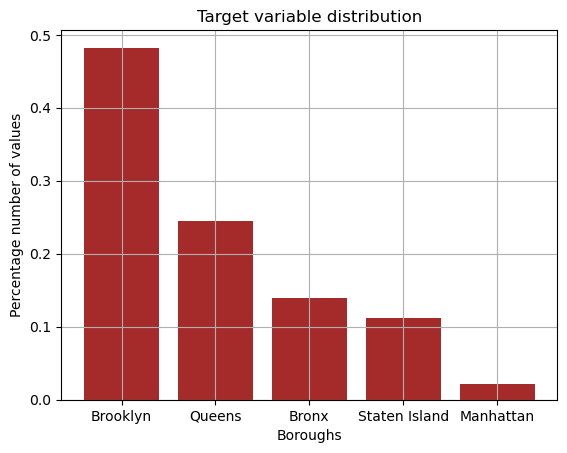

In [13]:
plt.bar(dist.index,dist.values,color = 'brown')
plt.grid()
plt.title('Target variable distribution')
plt.xlabel('Boroughs')
plt.ylabel('Percentage number of values')
plt.show()

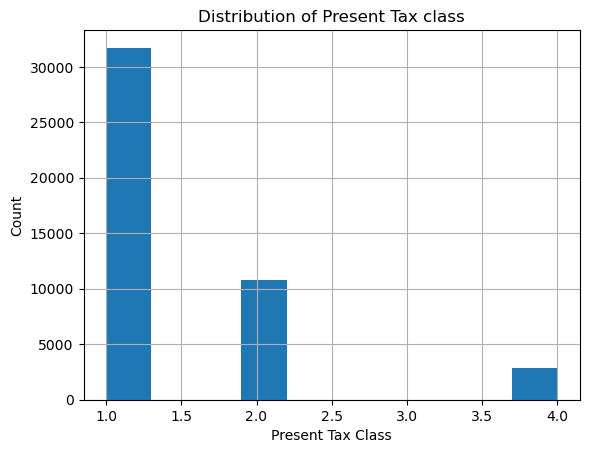

In [14]:
plt.hist(df['TAX CLASS AT TIME OF SALE'])
plt.grid()
plt.title('Distribution of Present Tax class')
plt.xlabel('Present Tax Class')
plt.ylabel('Count')
plt.show()

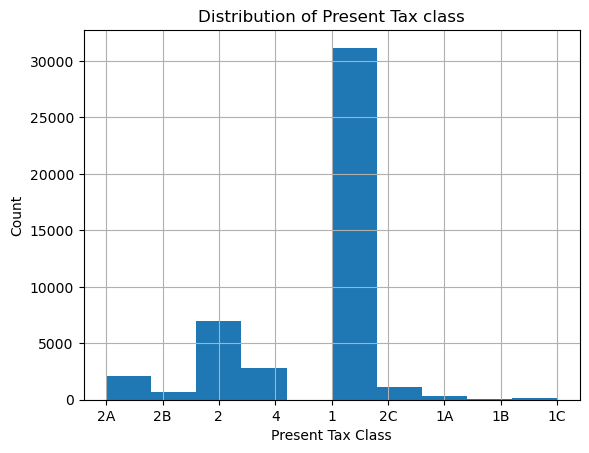

In [15]:
plt.hist(df['TAX CLASS AT PRESENT'])
plt.grid()
plt.title('Distribution of Present Tax class')
plt.xlabel('Present Tax Class')
plt.ylabel('Count')
plt.show()

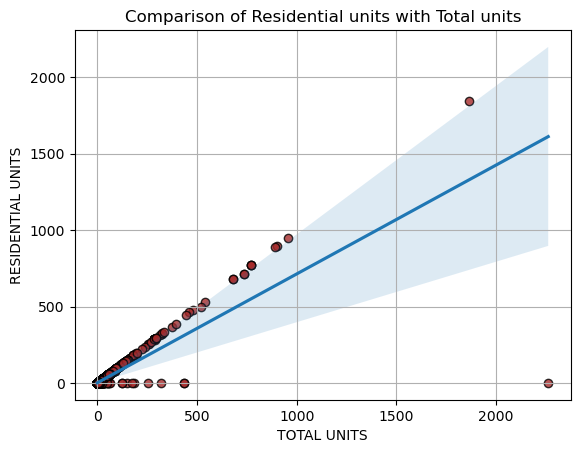

In [16]:
sns.regplot(data=df,x='TOTAL UNITS',y = 'RESIDENTIAL UNITS',scatter_kws={'ec':'k','color':'brown'})
plt.grid()
plt.title("Comparison of Residential units with Total units")
plt.savefig('Residential VS Total.png',dpi = 300,bbox_inches = 'tight')
plt.show()

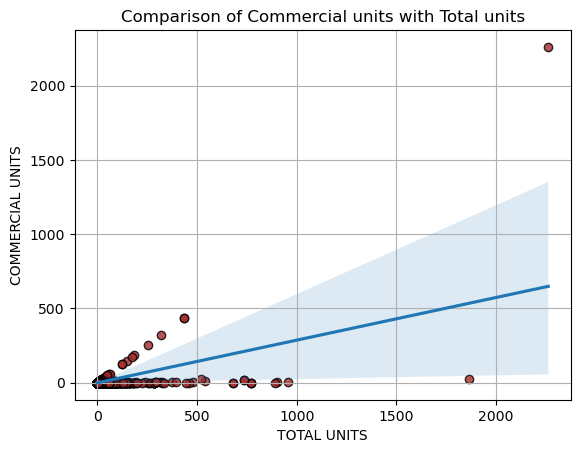

In [17]:
sns.regplot(data=df,x='TOTAL UNITS',y = 'COMMERCIAL UNITS',scatter_kws={'ec':'k','color':'brown'})
plt.grid()
plt.title("Comparison of Commercial units with Total units")
plt.savefig('Commercial VS Total.png',dpi = 300,bbox_inches = 'tight')
plt.show()

In [18]:
df.columns

Index(['BOROUGH', 'TAX CLASS AT PRESENT', 'RESIDENTIAL UNITS',
       'COMMERCIAL UNITS', 'TOTAL UNITS', 'LAND SQUARE FEET',
       'GROSS SQUARE FEET', 'YEAR BUILT', 'TAX CLASS AT TIME OF SALE',
       'SALE PRICE'],
      dtype='object')

<Figure size 2000x1000 with 0 Axes>

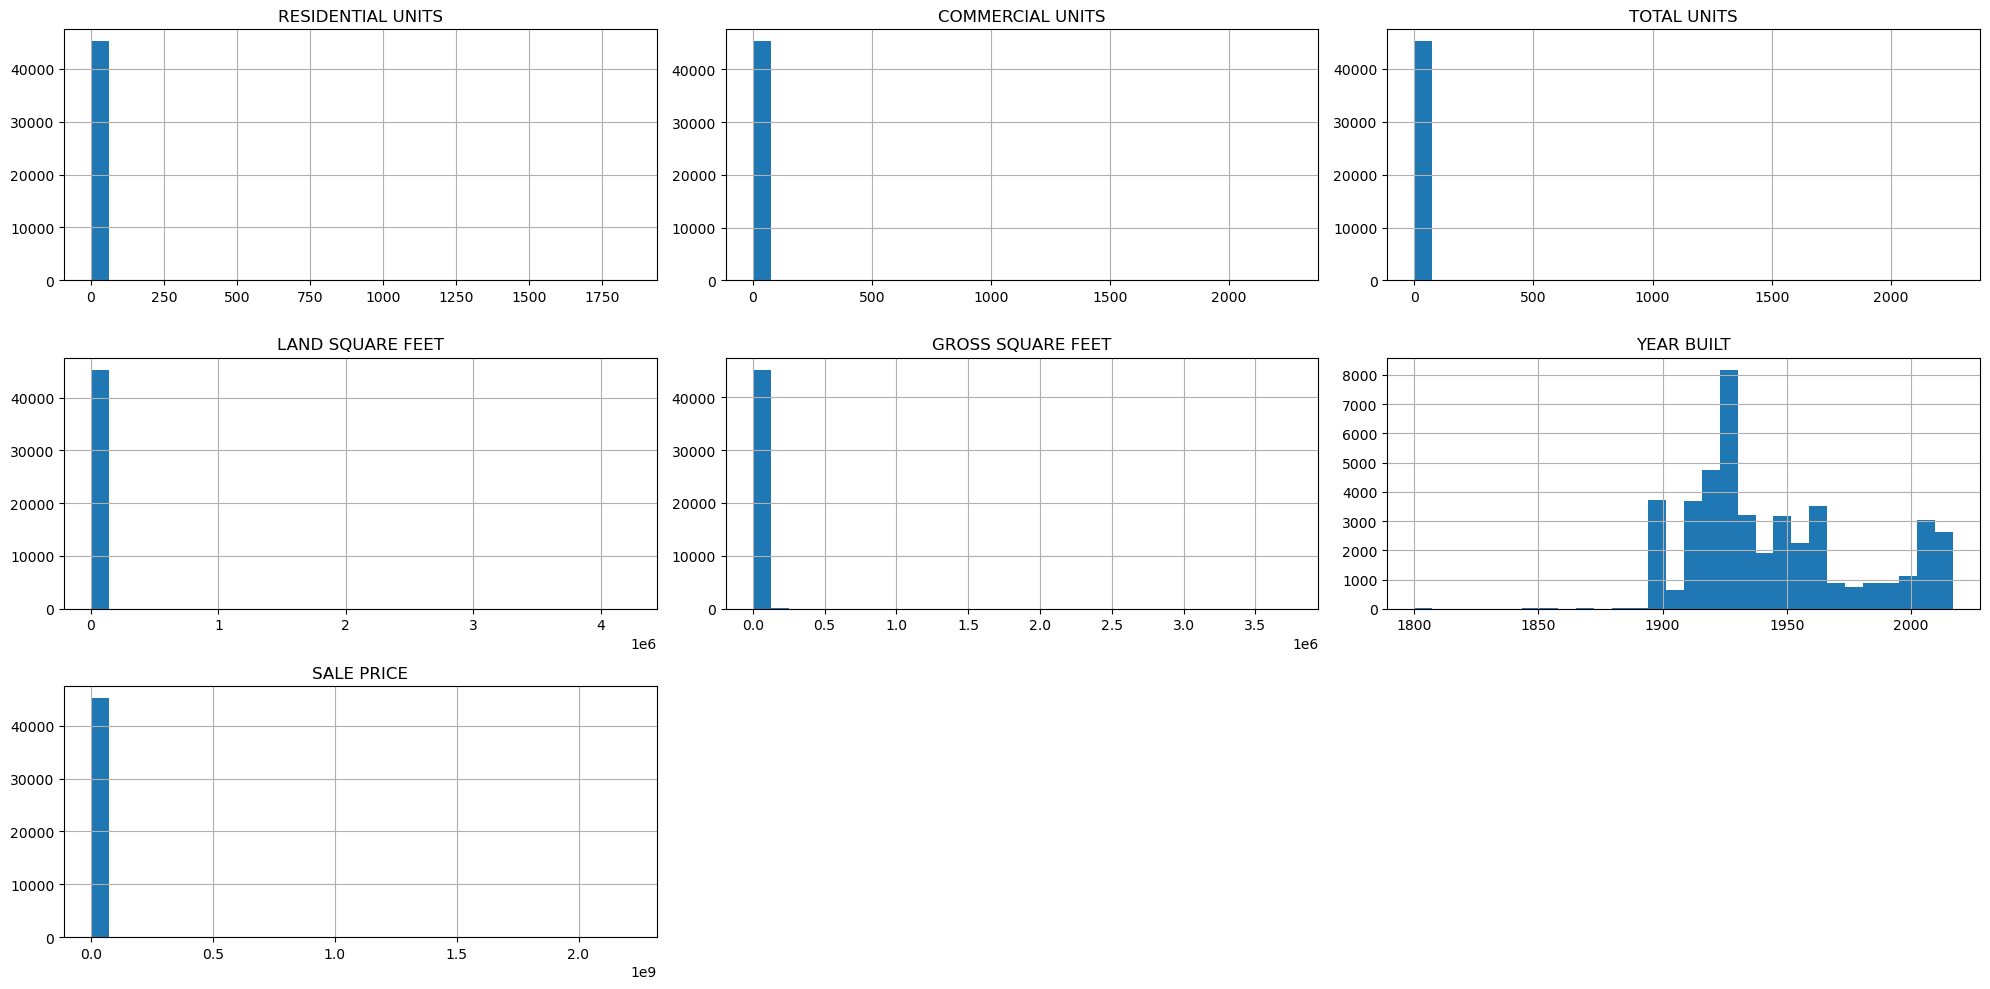

In [19]:
plt.figure(figsize=(20,10))
df.select_dtypes(include='number').hist(bins=30,figsize=(20,10))
plt.tight_layout()
plt.show()

In [20]:
df.select_dtypes('number').columns

Index(['RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT', 'SALE PRICE'],
      dtype='object')

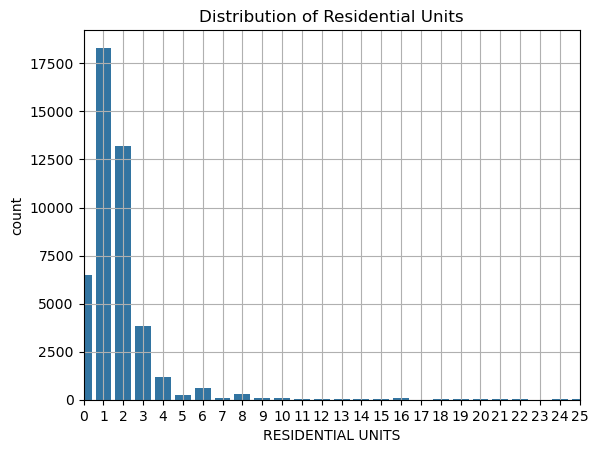

In [21]:
sns.countplot(data=df,x = 'RESIDENTIAL UNITS')
plt.xlim(0,25)
plt.title('Distribution of Residential Units')
plt.grid()
plt.savefig('dist.png',dpi = 300,bbox_inches = 'tight')
plt.show()

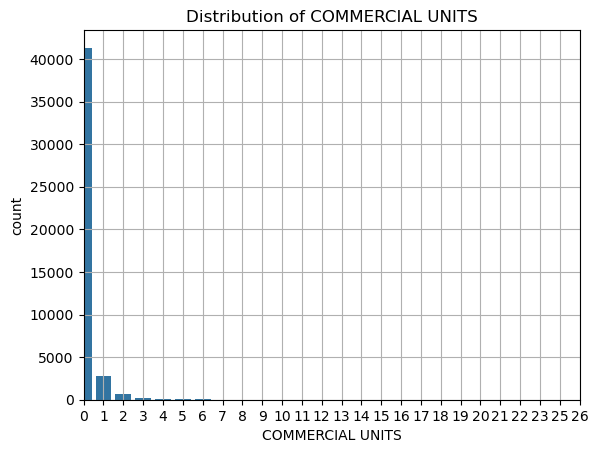

In [22]:
sns.countplot(data=df,x = 'COMMERCIAL UNITS')
plt.xlim(0,25)
plt.title('Distribution of COMMERCIAL UNITS')
plt.grid()
plt.savefig('dist.png',dpi = 300,bbox_inches = 'tight')
plt.show()

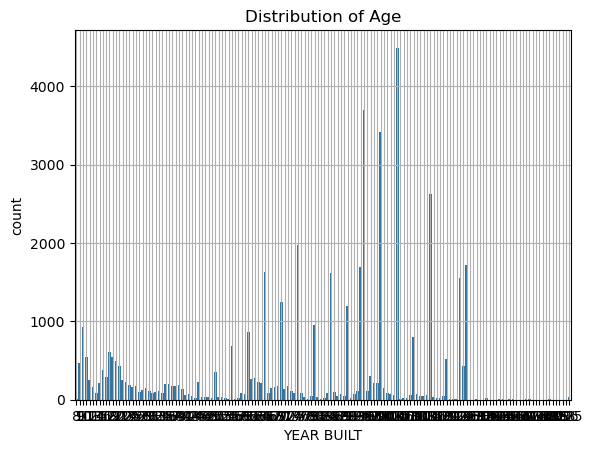

In [23]:
new = 2025-df['YEAR BUILT']
sns.countplot(x = new)
plt.title('Distribution of Age')
plt.grid()
plt.savefig('dist.png',dpi = 300,bbox_inches = 'tight')
plt.show()

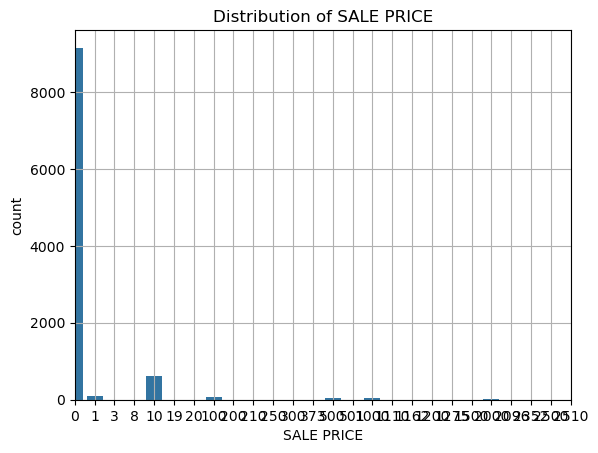

In [24]:
sns.countplot(data=df,x = 'SALE PRICE')
plt.xlim(0,25)
plt.title('Distribution of SALE PRICE')
plt.grid()
plt.savefig('dist.png',dpi = 300,bbox_inches = 'tight')
plt.show()

In [25]:
df.head()

,BOROUGH,TAX CLASS AT PRESENT,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,SALE PRICE
0,Manhattan,2A,5,0,5,1633,6440,1900,2,6625000
3,Manhattan,2B,10,0,10,2272,6794,1913,2,3936272
4,Manhattan,2A,6,0,6,2369,4615,1900,2,8000000
6,Manhattan,2B,8,0,8,1750,4226,1920,2,3192840
9,Manhattan,2,24,0,24,4489,18523,1920,2,16232000


## Data Preparation and Preprocessing

Data preparation

In [26]:
#Converting YEAR BUILT into age of the builing
df['YEAR BUILT'] = 2025-df['YEAR BUILT']
df = df.rename(columns={'YEAR BUILT':'BUILDING AGE'})

In [27]:
#X and y split
X=df.drop('BOROUGH',axis = 1)
y = df['BOROUGH']

Train, Test and Valid split

In [28]:
X_train,X_test_full,y_train,y_test_full = train_test_split(X,y,train_size=0.7,random_state=42,stratify=y)
X_test,X_valid,y_test,y_valid = train_test_split(X_test_full,y_test_full,train_size=0.5,random_state=42,stratify=y_test_full)

Preprocessing Pipeline

In [29]:
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes('object').columns
log_trans = FunctionTransformer(np.log1p)

num_pipe = Pipeline([
    ('impute',SimpleImputer(strategy='median')),
    ('log_transform',log_trans),
    ('scale',StandardScaler())
])

cat_pipe = Pipeline([
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('encode',OneHotEncoder(drop = 'first',handle_unknown='ignore',sparse_output=False))
])

preprocessing = ColumnTransformer([
    ('numeric',num_pipe,num_cols),
    ('categoric',cat_pipe,cat_cols)
])

Handling Unbalanced target variable

In [30]:
balance_data_check = Imbpipeline([
    ('preprocessing',preprocessing),
    ('undersampling',RandomUnderSampler(sampling_strategy={'Brooklyn':2700,'Queens':2700,'Bronx':2700,'Staten Island':2700},random_state=42)),
    ('smote',SMOTE(sampling_strategy={'Manhattan':2700},random_state=42,k_neighbors=3))
])

In [31]:
X_check,y_check = balance_data_check.fit_resample(X_train,y_train)

Balance check

In [32]:
#Before Balancing
print(y_train.value_counts())

BOROUGH
Brooklyn         15305
Queens            7750
Bronx             4430
Staten Island     3544
Manhattan          704
Name: count, dtype: int64


In [33]:
#After  Balancing
print(y_check.value_counts())

BOROUGH
Bronx            2700
Brooklyn         2700
Manhattan        2700
Queens           2700
Staten Island    2700
Name: count, dtype: int64


## Model Training and Evaluation

**1. Logistic Regression**

- Balanced Model

In [34]:
logistic_model_balanced = Imbpipeline([
    ('Preprocessing',preprocessing),
    ('undersampling',RandomUnderSampler(random_state=42,sampling_strategy={'Brooklyn':2700,'Queens':2700,'Bronx':2700,'Staten Island':2700})),
    ('smote',SMOTE(sampling_strategy={'Manhattan':2700},random_state=42,k_neighbors=3)),
    ('model',LogisticRegression())
])

In [35]:
GV_log_balanced = GridSearchCV(estimator=logistic_model_balanced,param_grid={'model__C':np.logspace(-3,2,10)},
                     cv = 5,verbose=1,scoring='f1_macro',
                     n_jobs=-1,return_train_score=True)
GV_log_balanced.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('Preprocessing',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('log_transform',
                                                                                          FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                         ('scale',
                                                                                          StandardScaler())]),
                                                                         Index(['RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'BUILD...
                                        SMOTE(k_neighbors=3, random_state=42,
                                              sampling_strategy={'Manhattan': 2700})),
                                       ('model', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'model__C': array([1.00000000e-03, 3.59381366e-03, 1.29154967e-02, 4.64158883e-02,
       1.66810054e-01, 5.99484250e-01, 2.15443469e+00, 7.74263683e+00,
       2.78255940e+01, 1.00000000e+02])},
             return_train_score=True, scoring='f1_macro', verbose=1)

In [36]:
print(f'Best Parameter:{GV_log_balanced.best_params_}')
print(f'Best score:{GV_log_balanced.best_score_}')

Best Parameter:{'model__C': 27.825594022071257}
Best score:0.4772214006821101


In [37]:
log_results_balanced = GV_log_balanced.cv_results_
log_results_balanced = pd.DataFrame(log_results_balanced)

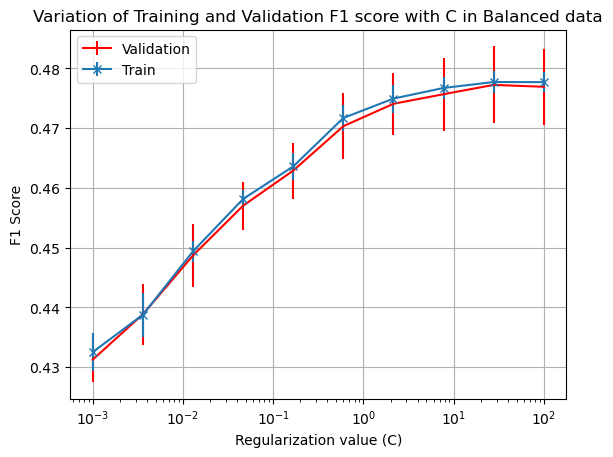

In [38]:
plt.errorbar(x=log_results_balanced['param_model__C'],y=log_results_balanced['mean_test_score'],yerr=log_results_balanced['std_test_score'],label = 'Validation',color = 'red')
plt.errorbar(x=log_results_balanced['param_model__C'],y=log_results_balanced['mean_train_score'],yerr=log_results_balanced['std_train_score'],label = 'Train',marker = 'x')
plt.xlabel('Regularization value (C)')
plt.ylabel('F1 Score')
plt.title('Variation of Training and Validation F1 score with C in Balanced data')
plt.xscale('log')
plt.grid()
plt.legend()
plt.savefig('Balanced Logi.png',dpi = 300,bbox_inches = 'tight')
plt.show()

In [39]:
log_pred = GV_log_balanced.best_estimator_.predict(X_test)
print(f'F1 score:{f1_score(y_test,log_pred,average='macro'):.2f}')
print(f'Accuracy:{accuracy_score(y_test,log_pred):.2f}')
print(classification_report(y_test,log_pred))

F1 score:0.47
Accuracy:0.53
               precision    recall  f1-score   support

        Bronx       0.23      0.18      0.21       949
     Brooklyn       0.82      0.52      0.63      3279
    Manhattan       0.27      0.91      0.41       151
       Queens       0.47      0.66      0.55      1661
Staten Island       0.48      0.70      0.57       760

     accuracy                           0.53      6800
    macro avg       0.45      0.60      0.47      6800
 weighted avg       0.60      0.53      0.54      6800



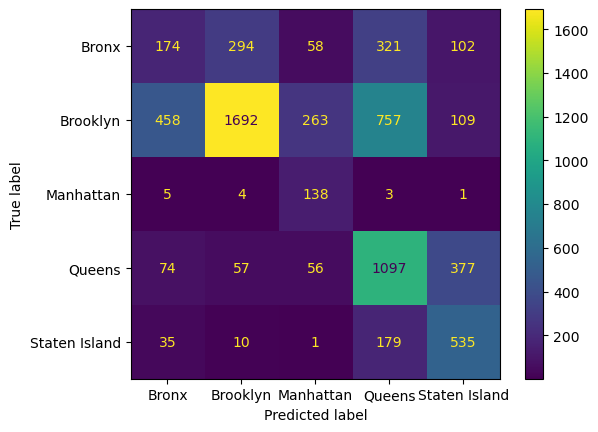

In [40]:
ConfusionMatrixDisplay.from_predictions(y_test,log_pred)
plt.show()

- Unbalanced Model

In [41]:
logistic_model_unbalanced = Pipeline([
    ('Preprocessing',preprocessing),
    ('model',LogisticRegression())
])

In [42]:
GV_log_unbalanced = GridSearchCV(estimator=logistic_model_unbalanced,param_grid={'model__C':np.logspace(-3,2,10)},
                     cv = 5,verbose=1,scoring='f1_macro',
                     n_jobs=-1,return_train_score=True)
GV_log_unbalanced.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('Preprocessing',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('log_transform',
                                                                                          FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                         ('scale',
                                                                                          StandardScaler())]),
                                                                         Index(['RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'BUILD...
                                                                         Index(['TAX CLASS AT PRESENT', 'TAX CLASS AT TIME OF SALE'], dtype='object'))])),
                                       ('model', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'model__C': array([1.00000000e-03, 3.59381366e-03, 1.29154967e-02, 4.64158883e-02,
       1.66810054e-01, 5.99484250e-01, 2.15443469e+00, 7.74263683e+00,
       2.78255940e+01, 1.00000000e+02])},
             return_train_score=True, scoring='f1_macro', verbose=1)

In [43]:
print(f'Best Parameter:{GV_log_unbalanced.best_params_}')
print(f'Best score:{GV_log_unbalanced.best_score_}')

Best Parameter:{'model__C': 27.825594022071257}
Best score:0.48439781114336167


In [44]:
log_results_unbalanced = GV_log_unbalanced.cv_results_
log_results_unbalanced = pd.DataFrame(log_results_unbalanced)

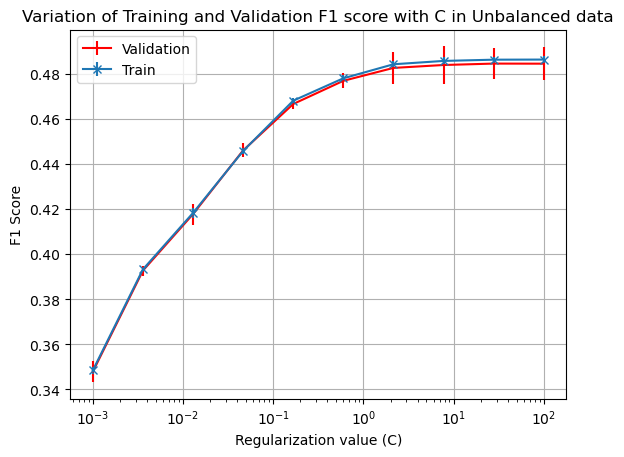

In [45]:
plt.errorbar(x=log_results_unbalanced['param_model__C'],y=log_results_unbalanced['mean_test_score'],yerr=log_results_unbalanced['std_test_score'],label = 'Validation',color = 'red')
plt.errorbar(x=log_results_unbalanced['param_model__C'],y=log_results_unbalanced['mean_train_score'],yerr=log_results_unbalanced['std_train_score'],label = 'Train',marker = 'x')
plt.xlabel('Regularization value (C)')
plt.ylabel('F1 Score')
plt.title('Variation of Training and Validation F1 score with C in Unbalanced data')
plt.xscale('log')
plt.grid()
plt.legend()
plt.savefig('UnBalanced Logi.png',dpi = 300,bbox_inches = 'tight')
plt.show()

In [46]:
log_pred_UnB = GV_log_unbalanced.best_estimator_.predict(X_test)
print(f'F1 score:{f1_score(y_test,log_pred_UnB,average='macro'):.2f}')
print(f'Accuracy:{accuracy_score(y_test,log_pred_UnB):.2f}')
print(classification_report(y_test,log_pred_UnB))

F1 score:0.48
Accuracy:0.63
               precision    recall  f1-score   support

        Bronx       0.18      0.01      0.01       949
     Brooklyn       0.70      0.83      0.76      3279
    Manhattan       0.62      0.54      0.57       151
       Queens       0.52      0.72      0.61      1661
Staten Island       0.65      0.36      0.46       760

     accuracy                           0.63      6800
    macro avg       0.53      0.49      0.48      6800
 weighted avg       0.57      0.63      0.58      6800



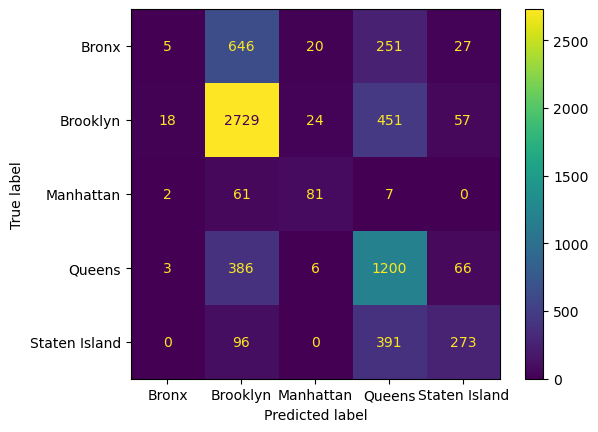

In [47]:
ConfusionMatrixDisplay.from_predictions(y_test,log_pred_UnB)
plt.show()

**2. DecisionTreeClassifier**

In [48]:
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes('object').columns

num_pipe = Pipeline([
    ('impute',SimpleImputer(strategy='median'))
])

cat_pipe = Pipeline([
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('encode',OneHotEncoder(drop = 'first',handle_unknown='ignore',sparse_output=False))
])

Preprocessing = ColumnTransformer([
    ('numeric',num_pipe,num_cols),
    ('categoric',cat_pipe,cat_cols)
])

In [49]:
DT_model = Pipeline([
    ('Preprocessing',Preprocessing),
    ('model',DecisionTreeClassifier())
])

In [50]:
GV_DT = GridSearchCV(estimator=DT_model,cv = 5,verbose=1,n_jobs=-1,
                        param_grid={'model__max_depth':np.arange(1,15)},
                        scoring='f1_macro',return_train_score=True)
GV_DT.fit(X_train,y_train)

Fitting 5 folds for each of 14 candidates, totalling 70 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('Preprocessing',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         Index(['RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'BUILDING AGE', 'SALE PRICE'],
      dtype='object')),
                                                                        ('categoric',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImp...y='most_frequent')),
                                                                                         ('encode',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         Index(['TAX CLASS AT PRESENT', 'TAX CLASS AT TIME OF SALE'], dtype='object'))])),
                                       ('model', DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'model__max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])},
             return_train_score=True, scoring='f1_macro', verbose=1)

In [51]:
print(f'Best Parameter:{GV_DT.best_params_}')
print(f'Best score:{GV_DT.best_score_}')

Best Parameter:{'model__max_depth': 13}
Best score:0.6726098725642806


In [52]:
DT_results = GV_DT.cv_results_
DT_results = pd.DataFrame(DT_results)

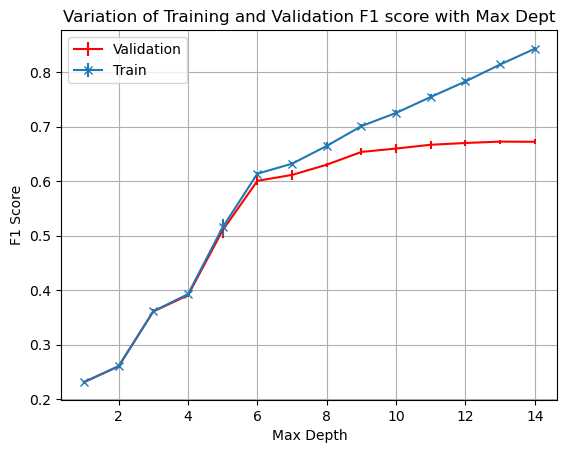

In [53]:
plt.errorbar(x=DT_results['param_model__max_depth'],y=DT_results['mean_test_score'],yerr=DT_results['std_test_score'],label = 'Validation',color = 'red')
plt.errorbar(x=DT_results['param_model__max_depth'],y=DT_results['mean_train_score'],yerr=DT_results['std_train_score'],label = 'Train',marker = 'x')
plt.xlabel('Max Depth')
plt.ylabel('F1 Score')
plt.title('Variation of Training and Validation F1 score with Max Dept')
plt.grid()
plt.legend()
plt.savefig('DT.png',dpi = 300,bbox_inches = 'tight')
plt.show()

In [54]:
DT_pred = GV_DT.best_estimator_.predict(X_test)
print(f'F1 score:{f1_score(y_test,DT_pred,average='macro'):.2f}')
print(f'Accuracy:{accuracy_score(y_test,DT_pred):.2f}')
print(classification_report(y_test,DT_pred))

F1 score:0.68
Accuracy:0.72
               precision    recall  f1-score   support

        Bronx       0.52      0.41      0.46       949
     Brooklyn       0.80      0.82      0.81      3279
    Manhattan       0.76      0.64      0.70       151
       Queens       0.64      0.73      0.68      1661
Staten Island       0.77      0.69      0.73       760

     accuracy                           0.72      6800
    macro avg       0.70      0.66      0.68      6800
 weighted avg       0.72      0.72      0.72      6800



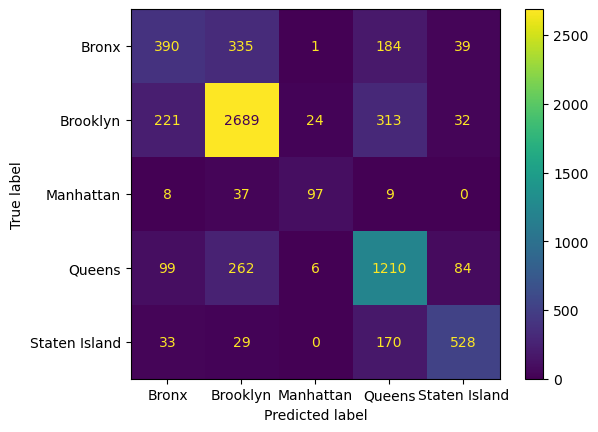

In [55]:
ConfusionMatrixDisplay.from_predictions(y_test,DT_pred)
plt.show()

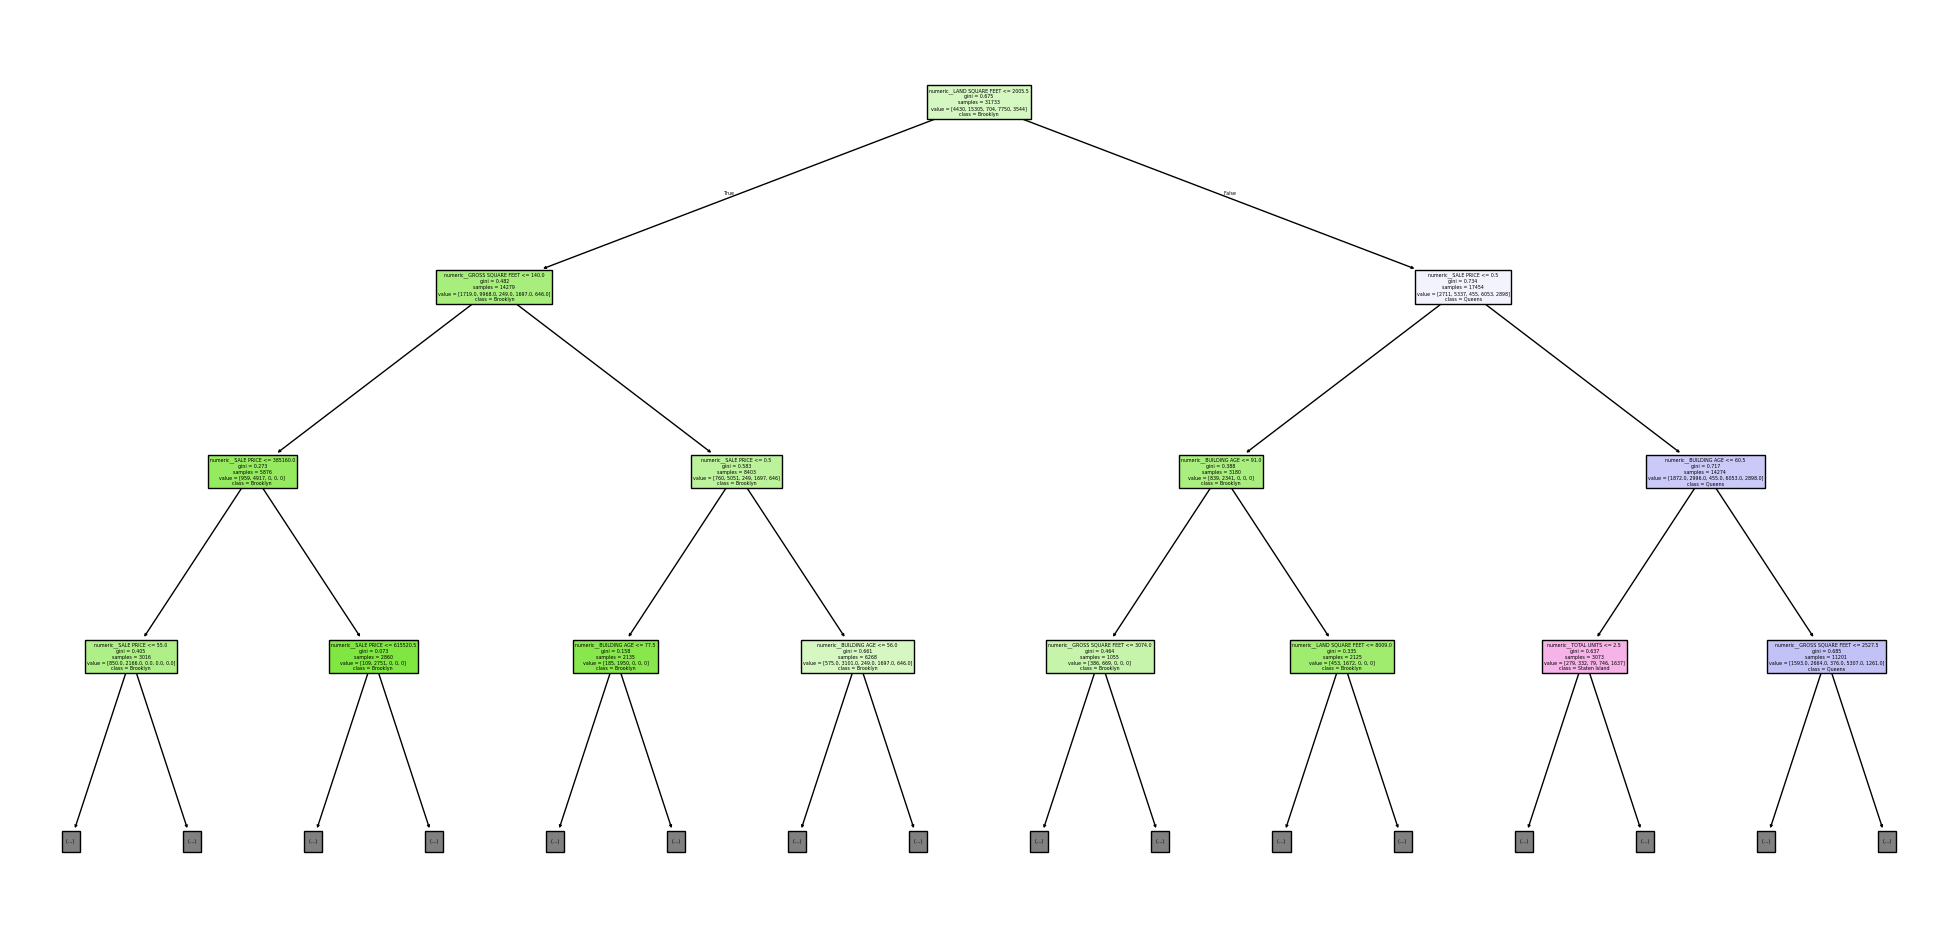

In [56]:
plt.figure(figsize=(25,12))
plot_tree(GV_DT.best_estimator_.named_steps['model'],feature_names=GV_DT.best_estimator_.named_steps['Preprocessing'].get_feature_names_out(),max_depth=3,
         class_names=GV_DT.best_estimator_.named_steps['model'].classes_,filled=True)
plt.show()

**3.SVC**

In [57]:
#Down sampling the data as SVC takes a lot of time to process
resampled_df  = df.sample(1000,random_state= 42)
X_resampled = resampled_df.drop('BOROUGH',axis = 1)
y_resampled = resampled_df['BOROUGH']
X_train_resampled,X_test_resampled,y_train_resampled,y_test_resampled = train_test_split(X_resampled,y_resampled,random_state=42,train_size=0.8)

In [58]:
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes('object').columns
log_trans = FunctionTransformer(np.log1p)

num_pipe = Pipeline([
    ('impute',SimpleImputer(strategy='median')),
    ('log_transform',log_trans),
    ('scale',StandardScaler())
])

cat_pipe = Pipeline([
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('encode',OneHotEncoder(drop = 'first',handle_unknown='ignore',sparse_output=False))
])

preprocessing = ColumnTransformer([
    ('numeric',num_pipe,num_cols),
    ('categoric',cat_pipe,cat_cols)
])

In [59]:
SVC_model = Pipeline([
    ('preprocessing',preprocessing),
    ('model',SVC())
])

In [60]:
GV_SVC = GridSearchCV(estimator=SVC_model,n_jobs=-1,verbose=1,return_train_score=True,
                     cv = 5,scoring='f1_macro',param_grid={'model__kernel':['rbf','poly"'],
                                                            'model__C':np.logspace(0.1,3,10),
                                                          'model__gamma':np.linspace(0.1,5,10),
                                                          })
GV_SVC.fit(X_train_resampled,y_train_resampled)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


C:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
500 fits failed out of a total of 1000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 473, in fit
    self._final_estimator.fit(

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('log_transform',
                                                                                          FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                         ('scale',
                                                                                          StandardScaler())]),
                                                                         Index(['RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'BUILD...
             param_grid={'model__C': array([   1.25892541,    2.64376119,    5.55193591,   11.65914401,
         24.48436747,   51.41751828,  107.97751623,  226.75431259,
        476.1872663 , 1000.        ]),
                         'model__gamma': array([0.1       , 0.64444444, 1.18888889, 1.73333333, 2.27777778,
       2.82222222, 3.36666667, 3.91111111, 4.45555556, 5.        ]),
                         'model__kernel': ['rbf', 'poly"']},
             return_train_score=True, scoring='f1_macro', verbose=1)

In [61]:
print(f'Best Parameter:{GV_SVC.best_params_}')
print(f'Best score:{GV_SVC.best_score_}')

Best Parameter:{'model__C': 51.41751827683925, 'model__gamma': 5.0, 'model__kernel': 'rbf'}
Best score:0.5545775738105168


In [62]:
SVC_pred = GV_SVC.best_estimator_.predict(X_test_resampled)
print(f'F1 score:{f1_score(y_test_resampled,SVC_pred,average='macro'):.2f}')
print(f'Accuracy:{accuracy_score(y_test_resampled,SVC_pred):.2f}')
print(classification_report(y_test_resampled,SVC_pred))

F1 score:0.53
Accuracy:0.63
               precision    recall  f1-score   support

        Bronx       0.38      0.21      0.27        29
     Brooklyn       0.65      0.77      0.71        97
    Manhattan       0.50      0.25      0.33         4
       Queens       0.59      0.61      0.60        44
Staten Island       0.81      0.65      0.72        26

     accuracy                           0.63       200
    macro avg       0.58      0.50      0.53       200
 weighted avg       0.62      0.63      0.61       200



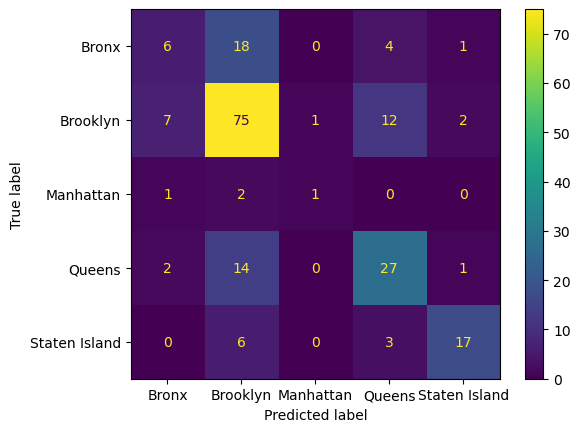

In [63]:
ConfusionMatrixDisplay.from_predictions(y_test_resampled,SVC_pred)
plt.show()

**4.Random Forest**

In [64]:
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes('object').columns

num_pipe = Pipeline([
    ('impute',SimpleImputer(strategy='median'))
])

cat_pipe = Pipeline([
    ('impute',SimpleImputer(strategy='most_frequent')),
    ('encode',OneHotEncoder(drop = 'first',handle_unknown='ignore',sparse_output=False))
])

Preprocessing = ColumnTransformer([
    ('numeric',num_pipe,num_cols),
    ('categoric',cat_pipe,cat_cols)
])

In [65]:
RF_model = Pipeline([
    ('Preprocessing',Preprocessing),
    ('model',RandomForestClassifier())
])

In [66]:
GV_RF = GridSearchCV(estimator=RF_model,n_jobs=-1,verbose=1,param_grid={
    'model__max_depth':np.arange(10,31,5),
    'model__n_estimators':np.arange(100,1000,100)
},cv = 5)
GV_RF.fit(X_train,y_train)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('Preprocessing',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         Index(['RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'BUILDING AGE', 'SALE PRICE'],
      dtype='object')),
                                                                        ('categoric',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImp...t_frequent')),
                                                                                         ('encode',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         Index(['TAX CLASS AT PRESENT', 'TAX CLASS AT TIME OF SALE'], dtype='object'))])),
                                       ('model', RandomForestClassifier())]),
             n_jobs=-1,
             param_grid={'model__max_depth': array([10, 15, 20, 25, 30]),
                         'model__n_estimators': array([100, 200, 300, 400, 500, 600, 700, 800, 900])},
             verbose=1)

In [67]:
print(f'Best Parameter:{GV_RF.best_params_}')
print(f'Best score:{GV_RF.best_score_}')

Best Parameter:{'model__max_depth': 20, 'model__n_estimators': 500}
Best score:0.7571299632042873


In [68]:
RF_pred = GV_RF.best_estimator_.predict(X_test)
print(f'F1 score:{f1_score(y_test,RF_pred,average='macro'):.2f}')
print(f'Accuracy:{accuracy_score(y_test,RF_pred):.2f}')
print(classification_report(y_test,RF_pred))

F1 score:0.72
Accuracy:0.76
               precision    recall  f1-score   support

        Bronx       0.62      0.45      0.52       949
     Brooklyn       0.81      0.85      0.83      3279
    Manhattan       0.78      0.74      0.76       151
       Queens       0.68      0.77      0.72      1661
Staten Island       0.80      0.74      0.77       760

     accuracy                           0.76      6800
    macro avg       0.74      0.71      0.72      6800
 weighted avg       0.75      0.76      0.75      6800



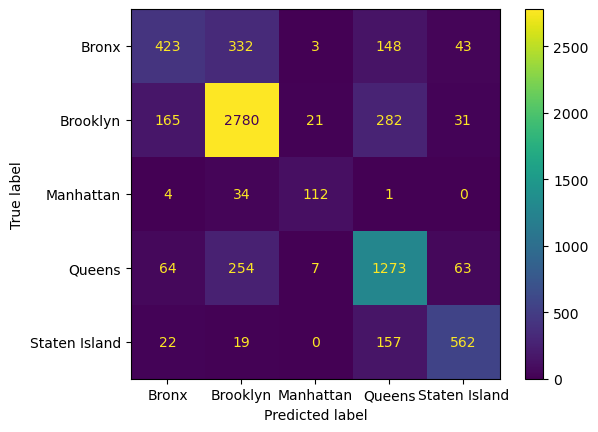

In [69]:
ConfusionMatrixDisplay.from_predictions(y_test,RF_pred)
plt.show()

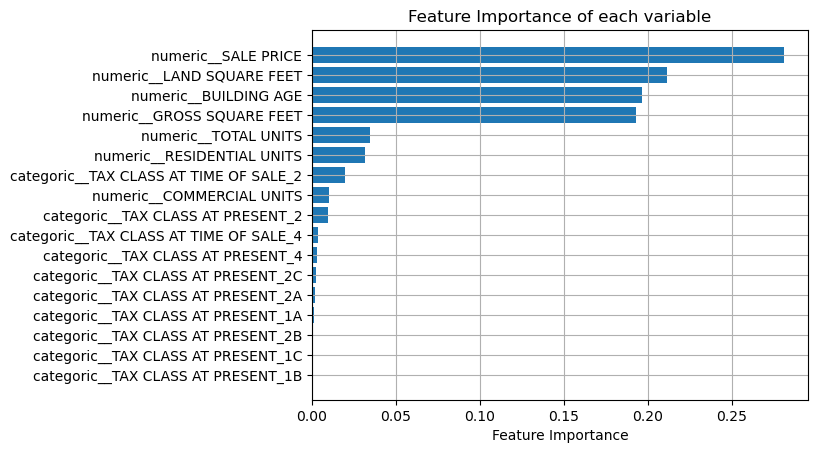

In [70]:
feature = GV_RF.best_estimator_.named_steps['Preprocessing'].get_feature_names_out()
feature_imp  = GV_RF.best_estimator_.named_steps['model'].feature_importances_

sorted_idx = np.argsort(feature_imp)[::1]
plt.barh(y = feature[sorted_idx],width = feature_imp[sorted_idx])
plt.title('Feature Importance of each variable')
plt.xlabel('Feature Importance')
plt.grid()
plt.savefig('RF.png',dpi = 300,bbox_inches = 'tight')
plt.show()

**5.Gradient Boosting**

In [71]:
#Using Preprocessing pipeline without scaling
GB_model = Pipeline([
    ('Preprocessing',Preprocessing),
    ('model',GradientBoostingClassifier(max_depth=4,n_estimators=500,
                                        n_iter_no_change=10,learning_rate=0.5,
                                       random_state=42))
])
GB_model.fit(X_train,y_train)

Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'BUILDING AGE', 'SALE PRICE'],
      dtype='object')),
                                                 ('categoric',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['TAX CLASS AT PRESENT', 'TAX CLASS AT TIME OF SALE'], dtype='object'))])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.5, max_depth=4,
                                            n_estimators=500,
                                            n_iter_no_change=10,
                                            random_state=42))])

In [72]:
print(f'Number of trees used by the model:{GB_model[-1].n_estimators_}')

Number of trees used by the model:14


In [73]:
train_pred = GB_model.predict(X_train)
print(f'Test Score:{f1_score(y_train,train_pred,average='macro')}')

Test Score:0.7089777745493591


In [74]:
GB_pred = GB_model.predict(X_test)
print(f'F1 score:{f1_score(y_test,GB_pred,average='macro'):.2f}')
print(f'Accuracy:{accuracy_score(y_test,GB_pred):.2f}')
print(classification_report(y_test,GB_pred))

F1 score:0.67
Accuracy:0.73
               precision    recall  f1-score   support

        Bronx       0.59      0.36      0.44       949
     Brooklyn       0.79      0.83      0.81      3279
    Manhattan       0.68      0.60      0.64       151
       Queens       0.64      0.74      0.69      1661
Staten Island       0.77      0.73      0.75       760

     accuracy                           0.73      6800
    macro avg       0.70      0.65      0.67      6800
 weighted avg       0.72      0.73      0.72      6800



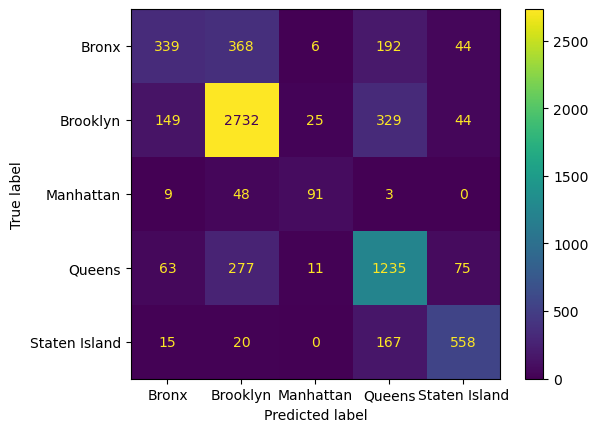

In [75]:
ConfusionMatrixDisplay.from_predictions(y_test,GB_pred)
plt.show()

**6.Neural Networks**

In [76]:
# Using preprocessing pipeline with scaling
X_train_NN = preprocessing.fit_transform(X_train)
X_test_NN = preprocessing.transform(X_test)
X_valid_NN = preprocessing.transform(X_valid)

le = LabelEncoder()
y_train_NN = le.fit_transform(y_train)
y_test_NN = le.transform(y_test)
y_valid_NN = le.transform(y_valid)

Model 1

In [106]:
model_01 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=X_train_NN.shape[1:]),
    tf.keras.layers.Dense(10,activation='relu'),
    tf.keras.layers.Dense(10,activation='relu'),
    tf.keras.layers.Dense(5,activation='softmax')
])
model_01.compile(loss='sparse_categorical_crossentropy',
                 optimizer='adam',
                 metrics=['accuracy']
                )
early_stop = tf.keras.callbacks.EarlyStopping(patience=10,restore_best_weights=True)

In [107]:
history = model_01.fit(X_train_NN,y_train_NN,epochs=100,callbacks=early_stop,
                       validation_data=(X_valid_NN,y_valid_NN))

Epoch 1/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5003 - loss: 1.2376 - val_accuracy: 0.6228 - val_loss: 0.9297
Epoch 2/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6360 - loss: 0.9065 - val_accuracy: 0.6465 - val_loss: 0.8799
Epoch 3/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6489 - loss: 0.8698 - val_accuracy: 0.6537 - val_loss: 0.8530
Epoch 4/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6626 - loss: 0.8482 - val_accuracy: 0.6613 - val_loss: 0.8384
Epoch 5/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6559 - loss: 0.8398 - val_accuracy: 0.6637 - val_loss: 0.8326
Epoch 6/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6654 - loss: 0.8238 - val_accuracy: 0.6653 - val_loss: 0.8192
Epoch 7/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6662 - loss: 0.8085 - val_accuracy: 0.6684 - val_loss: 0.8116
Epoch 8/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6655 - loss: 0.8120 - val_accu

In [108]:
loss,accuracy = model_01.evaluate(X_test_NN,y_test_NN)
print(f'Loss:{loss:.2f}')
print(f'Accuracy:{accuracy:.2f}')

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 929us/step - accuracy: 0.7146 - loss: 0.6992
Loss:0.71
Accuracy:0.71


Model 2

In [109]:
model_02 = tf.keras.Sequential([
    tf.keras.layers.Input(shape = X_train_NN.shape[1:]),
    tf.keras.layers.Dense(100,activation='relu'),
    tf.keras.layers.Dense(10,activation='relu'),
    tf.keras.layers.Dense(10,activation='relu'),
    tf.keras.layers.Dense(10,activation='relu'),
    tf.keras.layers.Dense(10,activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(5,activation='softmax')
])
model_02.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
early_stop = tf.keras.callbacks.EarlyStopping(patience=10,restore_best_weights=True)

In [110]:
history_02 = model_02.fit(X_train_NN,y_train_NN,
             validation_data=(X_valid_NN,y_valid_NN),callbacks=early_stop,
             epochs=100)

Epoch 1/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5108 - loss: 1.1889 - val_accuracy: 0.6521 - val_loss: 0.8635
Epoch 2/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6376 - loss: 0.8869 - val_accuracy: 0.6687 - val_loss: 0.8036
Epoch 3/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6500 - loss: 0.8568 - val_accuracy: 0.6757 - val_loss: 0.7800
Epoch 4/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6603 - loss: 0.8228 - val_accuracy: 0.6718 - val_loss: 0.7756
Epoch 5/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6700 - loss: 0.8042 - val_accuracy: 0.6707 - val_loss: 0.7633
Epoch 6/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6608 - loss: 0.8067 - val_accuracy: 0.6778 - val_loss: 0.7631
Epoch 7/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6723 - loss: 0.7768 - val_accuracy: 0.6788 - val_loss: 0.7421
Epoch 8/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6696 - loss: 0.7751 - val_accu

In [111]:
loss,accuracy = model_02.evaluate(X_test_NN,y_test_NN)
print(f'Loss:{loss:.2f}')
print(f'Accuracy:{accuracy:.2f}')

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7159 - loss: 0.6750
Loss:0.68
Accuracy:0.71


Model 3

In [112]:
model_03 = tf.keras.Sequential([
    tf.keras.layers.Input(shape = X_train_NN.shape[1:]),
    tf.keras.layers.Dense(100,activation='relu'),
    tf.keras.layers.Dense(10,activation='relu'),
    tf.keras.layers.Dense(10,activation='relu'),
    tf.keras.layers.Dense(10,activation='relu'),
    tf.keras.layers.Dense(10,activation='relu'),
    tf.keras.layers.Dense(5,activation='softmax')
])
model_03.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
early_stop = tf.keras.callbacks.EarlyStopping(patience=10,restore_best_weights=True)

In [113]:
history_03 = model_03.fit(X_train_NN,y_train_NN,
             validation_data=(X_valid_NN,y_valid_NN),callbacks=early_stop,
             epochs=100)

Epoch 1/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5623 - loss: 1.1151 - val_accuracy: 0.6582 - val_loss: 0.8523
Epoch 2/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6606 - loss: 0.8375 - val_accuracy: 0.6582 - val_loss: 0.8168
Epoch 3/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6675 - loss: 0.8090 - val_accuracy: 0.6682 - val_loss: 0.7909
Epoch 4/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6700 - loss: 0.7961 - val_accuracy: 0.6726 - val_loss: 0.7823
Epoch 5/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6779 - loss: 0.7712 - val_accuracy: 0.6769 - val_loss: 0.7582
Epoch 6/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6819 - loss: 0.7621 - val_accuracy: 0.6863 - val_loss: 0.7489
Epoch 7/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6890 - loss: 0.7478 - val_accuracy: 0.6807 - val_loss: 0.7524
Epoch 8/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6875 - loss: 0.7388 - val_accu

In [114]:
loss,accuracy = model_03.evaluate(X_test_NN,y_test_NN)
print(f'Loss:{loss:.2f}')
print(f'Accuracy:{accuracy:.2f}')

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7256 - loss: 0.6563
Loss:0.66
Accuracy:0.72


Model 4

In [115]:
model_04 = tf.keras.Sequential([
    tf.keras.layers.Input(shape = X_train_NN.shape[1:]),
    tf.keras.layers.Dense(100,activation='relu'),
    tf.keras.layers.Dense(100,activation='relu'),
    tf.keras.layers.Dense(50,activation='relu'),
    tf.keras.layers.Dense(10,activation='relu'),
    tf.keras.layers.Dense(10,activation='relu'),
    tf.keras.layers.Dense(5,activation='softmax')
])
model_04.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
early_stop = tf.keras.callbacks.EarlyStopping(patience=10,restore_best_weights=True)

In [116]:
history_04 = model_04.fit(X_train_NN,y_train_NN,
             validation_data=(X_valid_NN,y_valid_NN),callbacks=early_stop,
             epochs=100)

Epoch 1/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5979 - loss: 1.0391 - val_accuracy: 0.6657 - val_loss: 0.8153
Epoch 2/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6688 - loss: 0.7982 - val_accuracy: 0.6763 - val_loss: 0.7622
Epoch 3/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6772 - loss: 0.7629 - val_accuracy: 0.6835 - val_loss: 0.7400
Epoch 4/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6868 - loss: 0.7331 - val_accuracy: 0.6929 - val_loss: 0.7165
Epoch 5/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6927 - loss: 0.7137 - val_accuracy: 0.7025 - val_loss: 0.7001
Epoch 6/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6985 - loss: 0.7026 - val_accuracy: 0.7021 - val_loss: 0.7068
Epoch 7/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7056 - loss: 0.6877 - val_accuracy: 0.7054 - val_loss: 0.7019
Epoch 8/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7051 - loss: 0.6882 - val_accu

In [117]:
loss,accuracy = model_04.evaluate(X_test_NN,y_test_NN)
print(f'Loss:{loss:.2f}')
print(f'Accuracy:{accuracy:.2f}')

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - accuracy: 0.7294 - loss: 0.6527
Loss:0.66
Accuracy:0.72


Model 5

In [118]:
model_05 = tf.keras.Sequential([
    tf.keras.layers.Input(shape = X_train_NN.shape[1:]),
    tf.keras.layers.Dense(100,activation='relu'),
    tf.keras.layers.Dense(100,activation='relu'),
    tf.keras.layers.Dense(100,activation='relu'),
    tf.keras.layers.Dense(50,activation='relu'),
    tf.keras.layers.Dense(50,activation='relu'),
    tf.keras.layers.Dense(10,activation='relu'),
    tf.keras.layers.Dense(10,activation='relu'),
    tf.keras.layers.Dense(5,activation='softmax')
])
model_05.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
early_stop = tf.keras.callbacks.EarlyStopping(patience=10,restore_best_weights=True)

In [119]:
history_05 = model_05.fit(X_train_NN,y_train_NN,
             validation_data=(X_valid_NN,y_valid_NN),callbacks=early_stop,
             epochs=100)

Epoch 1/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5890 - loss: 1.0217 - val_accuracy: 0.6640 - val_loss: 0.7915
Epoch 2/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6641 - loss: 0.7852 - val_accuracy: 0.6860 - val_loss: 0.7343
Epoch 3/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6818 - loss: 0.7411 - val_accuracy: 0.6924 - val_loss: 0.7326
Epoch 4/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6889 - loss: 0.7205 - val_accuracy: 0.7110 - val_loss: 0.7009
Epoch 5/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6982 - loss: 0.7105 - val_accuracy: 0.7046 - val_loss: 0.7106
Epoch 6/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7013 - loss: 0.6996 - val_accuracy: 0.7084 - val_loss: 0.6943
Epoch 7/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7046 - loss: 0.6908 - val_accuracy: 0.7147 - val_loss: 0.6898
Epoch 8/100
992/992 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7111 - loss: 0.6847 - val_accu

In [120]:
loss,accuracy = model_05.evaluate(X_test_NN,y_test_NN)
print(f'Loss:{loss:.2f}')
print(f'Accuracy:{accuracy:.2f}')

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 992us/step - accuracy: 0.7347 - loss: 0.6555
Loss:0.66
Accuracy:0.73


**Evaluation of Model 4 (best performing model)**

In [121]:
loss,accuracy = model_04.evaluate(X_test_NN,y_test_NN)
print(f'Loss:{loss:.2f}')
print(f'Accuracy:{accuracy:.2f}')

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7294 - loss: 0.6527
Loss:0.66
Accuracy:0.72


In [122]:
NN_pred_prob = model_04.predict(X_test_NN)
NN_pred = np.argmax(NN_pred_prob,axis = 1)
print(f'F1 score:{f1_score(y_test_NN,NN_pred,average='macro'):.2f}')
print(f'Accuracy:{accuracy_score(y_test_NN,NN_pred):.2f}')
print(classification_report(y_test_NN,NN_pred))

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step
F1 score:0.68
Accuracy:0.72
              precision    recall  f1-score   support

           0       0.53      0.34      0.42       949
           1       0.79      0.83      0.81      3279
           2       0.72      0.72      0.72       151
           3       0.64      0.75      0.69      1661
           4       0.79      0.72      0.75       760

    accuracy                           0.72      6800
   macro avg       0.69      0.67      0.68      6800
weighted avg       0.72      0.72      0.72      6800



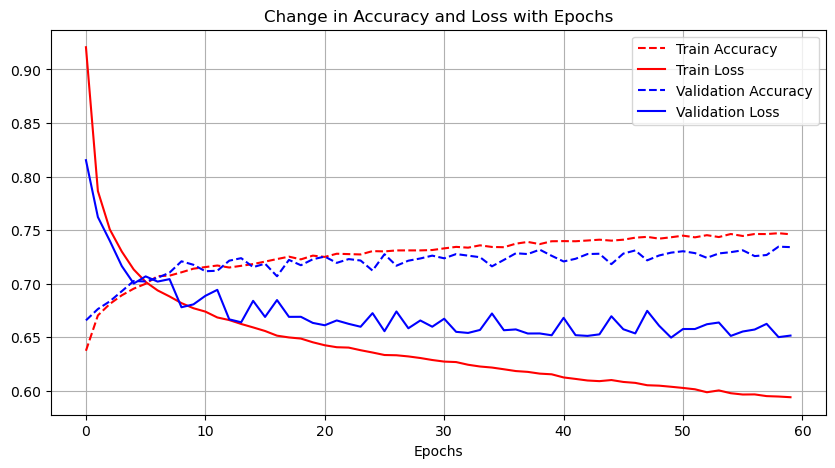

In [124]:
NN_results = pd.DataFrame(history_04.history)
NN_results.plot(style = ['r--','r','b--','b'],figsize = (10,5))
plt.title('Change in Accuracy and Loss with Epochs')
plt.xlabel('Epochs')
plt.legend(['Train Accuracy','Train Loss','Validation Accuracy','Validation Loss'])
plt.grid()
plt.savefig('NN.png',dpi = 300,bbox_inches = 'tight')
plt.show()